In [1]:
# ============================================================
# Notebook setup: run this before everything
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from util import util
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os

# Load data
data_folder = os.path.join('..', 'data', 'nab')
file_name = os.path.join('realKnownCause', 'nyc_taxi.csv')
data, labels, windows = util.load_series(file_name, data_folder)

# Train and validation end
train_end = pd.to_datetime('2014-10-24 00:00:00')
val_end = pd.to_datetime('2014-12-10 00:00:00')

# Cost model parameters
c_alrm = 1 # Cost of investigating a false alarm
c_missed = 10 # Cost of missing an anomaly
c_late = 5 # Cost for late detection

# Separate the training data
data_tr = data[data.index < train_end]

# Build a cost model
cmodel = util.ADSimpleCostModel(c_alrm, c_missed, c_late)

# Sliding Windows

## Temporal Correlations

**Let's have a closer look at our time series**

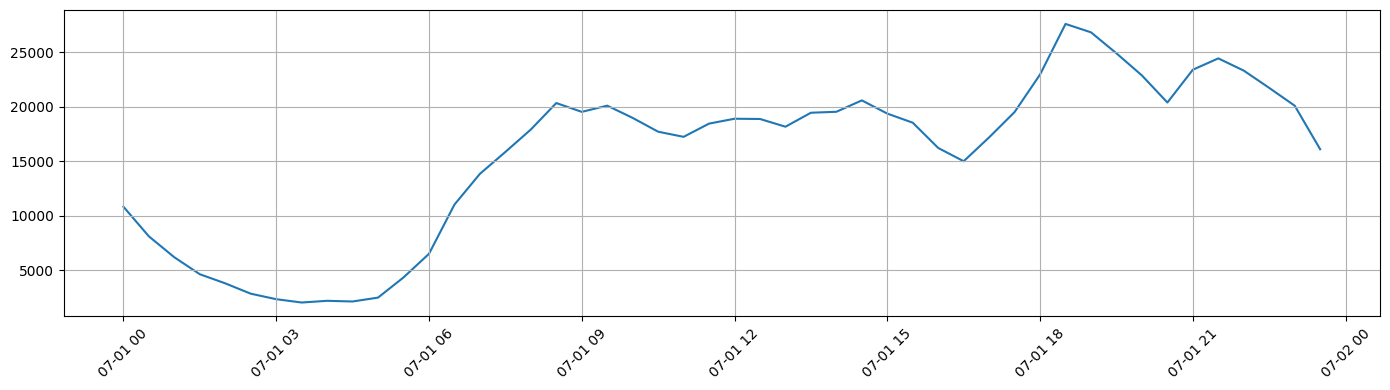

In [2]:
util.plot_series(data.iloc[:48], figsize=figsize)

* Nearby points tend to have similar values
* ...Meaning they are _correlated_

In time series data, temporal correlation refers to the relationship between values of the series at different time steps. This means that the value of the series at a given time is often influenced by its values at previous time steps.
In weather data, today's temperature is likely to be similar to yesterday's.
In stock prices, the price at one moment is often related to its price a few moments earlier.

## Determine the Correlation Interval

**How can we study such correlation?**

A useful tool: [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation) plots.
Autocorrelation measures the correlation of a time series with itself, but at different time lags. It helps us understand how the current value of the series is related to its past values.
- For example, a lag of 1 means comparing the current value with the value 1 time step earlier.
- A lag of 2 means comparing the current value with the value 2 time steps earlier, and so on.

Pearson Correlation Coefficient: This is a statistical measure of the linear relationship between two variables. It ranges from -1 to 1:

- 1: Perfect positive correlation (as one value increases, the other increases proportionally).
- -1: Perfect negative correlation (as one value increases, the other decreases proportionally).
- 0: No correlation (the two variables are independent).

To compute the autocorrelation for a time series:

1. Choose a range of lag values: Decide how many time steps (lags) you want to analyze. For example, you might want to check correlations for lags from 1 to 30.
2. For each lag l:
  - Shift the time series by l time steps.
  - Compute the Pearson Correlation Coefficient between the original series and the shifted series.
  - Plot the correlation coefficients: The x-axis represents the lag values, and the y-axis represents the correlation coefficients.

**Then we look at the resulting plot:**

* Where the curve is far from zero, there is a significant correlation
* Where it gets close to zero, no significant correlation exists

For example: If the autocorrelation plot shows high values for lags 1, 2, and 3, it means the series is strongly correlated with its values from 1, 2, and 3 time steps earlier.
If the autocorrelation plot drops to near zero after lag 5, it means the series has no significant correlation with values more than 5 time steps earlier.


## Temporal Correlations

**Let's have a look at our plot**

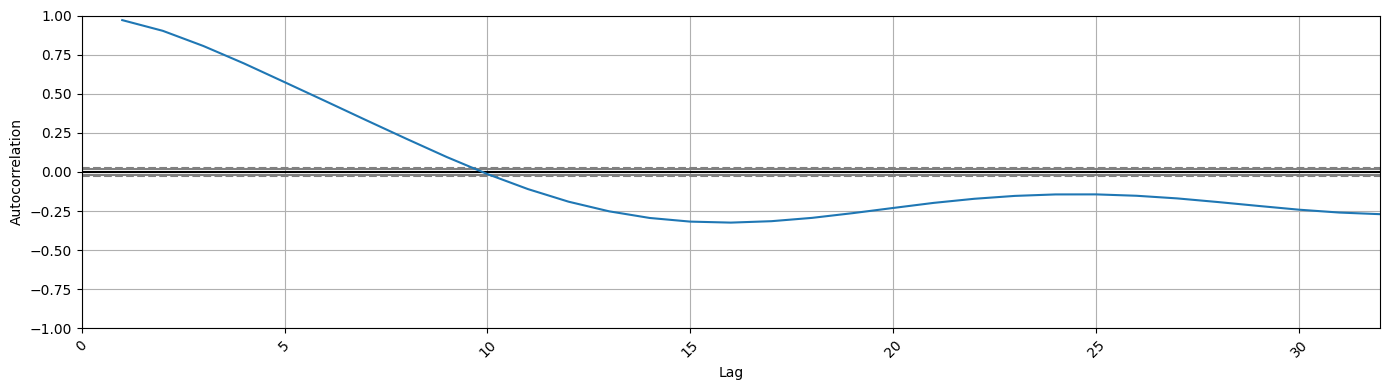

In [3]:
util.plot_autocorrelation(data, max_lag=32, figsize=figsize)

* The correlation is strong up to 4-5 lags

## Temporal Correlations

**These correlations are _a source of information_**

* They could be exploited to improve our estimated probabilities
* ...But our models so far make _no use_ of them

> **How can we take advantage of them?**

**For example, rather then feeding our model with individual observations**

We can use _sequences of observations_ as input

* This is a _very common approach_ in time series
* ...And in many cases it's a good idea

## Sliding Window

**A common approach consist in using a _sliding window_**

<center><img src="assets/sliding_window.svg" width="800px"/></center>

* We choose a _window length_ $w$, i.e. the length of each sub-sequence
* We place the "window" at the beginning of the series
* ...We extract the corresponding observations
* Then, we move the forward by a certain _stride_ and we repeat

## Sliding Window

**The result is a table**

Let $m$ be the number of examples and $w$ be the window length

|               | $\bf s_0$ | $\bf s_1$    | $\bf \ldots$ | $\bf s_{w-1}$ |
| ------------- | --------- | ------------ | ------------ | ------------- | 
| $\bf t_{w-1}$ | $x_0$     | $x_1$        | $\ldots$     | $x_{w-1}$     |
| $\bf t_{w}$   | $x_1$     | $x_2$        | $\ldots$     | $x_{w}$       |
| $\bf t_{w+1}$ | $x_2$     | $x_3$        | $\ldots$     | $x_{w+1}$     |
| $\bf \vdots$  | $\vdots$  | $\vdots$     | $\vdots$     | $\vdots$      |
| $\bf t_{m-1}$ | $x_{m-w}$ | $x_{m-w+1}$  | $\vdots$     | $x_{m-1}$     |

* The first window includes observations from $x_0$ to $x_{w-1}$
* The second from $x_1$ to $x_{w}$ and so on
* $t_i$ is the _time window index_ (where it was applied)
* $s_j$ is the _position_ of an observation _within a window_


## Sliding Window in pandas

**pandas provides a sliding window _iterator_**

```python
DataFrame.rolling(window, ...)
```

In [3]:
wlen = 20
for i, w in enumerate(data['value'].rolling(wlen)):
    print(w)
    if i == 2: break # We print the first three windows

timestamp
2014-07-01    10844.0
Name: value, dtype: float64
timestamp
2014-07-01 00:00:00    10844.0
2014-07-01 00:30:00     8127.0
Name: value, dtype: float64
timestamp
2014-07-01 00:00:00    10844.0
2014-07-01 00:30:00     8127.0
2014-07-01 01:00:00     6210.0
Name: value, dtype: float64


Notice how the first windows are not full (shorter than `wlen`).

## Sliding Window in pandas

**We can build our dataset using the `rolling` iterator**

* We discard the first `wlen-1` (incomplete) applications
* Then we store each window in a list, and we wrap everything in a `DataFrame`

In [ ]:
%%time
rows = []
for i, w in enumerate(data['value'].rolling(wlen)):
    if i >= wlen-1: rows.append(w.values)

wdata_index = data.index[wlen-1:]
wdata = pd.DataFrame(index=wdata_index, columns=range(wlen), data=rows)

CPU times: user 160 ms, sys: 1.39 ms, total: 161 ms
Wall time: 161 ms


* The `values` field allows access to the `Series` content as a numpy array
* We use it to _discard the index_
* ...Since the series for multiple iterations have inconsistent indexes

## Sliding Window in pandas

**This method works, but _it's a bit slow_**

* We are building our table by rows...
* ...But it is usually _faster to do it by columns_!
* After all, there are usually _fewer columns than rows_

**Let us look again at our table:**

|               | $\bf s_0$ | $\bf s_1$    | $\bf \ldots$ | $\bf s_{w-1}$ |
| ------------- | --------- | ------------ | ------------ | ------------- | 
| $\bf t_{w-1}$ | $x_0$     | $x_1$        | $\ldots$     | $x_{w-1}$     |
| $\bf t_{w}$   | $x_1$     | $x_2$        | $\ldots$     | $x_{w}$       |
| $\bf t_{w+1}$ | $x_2$     | $x_3$        | $\ldots$     | $x_{w+1}$     |
| $\bf \vdots$  | $\vdots$  | $\vdots$     | $\vdots$     | $\vdots$      |
| $\bf t_{m-1}$ | $x_{m-w}$ | $x_{m-w+1}$  | $\vdots$     | $x_{m-1}$     |

## Sliding Window in pandas

**We can build the columns by _slicing the original `DataFrame`_**

In [6]:
m = len(data)
c0 = data.iloc[0:m-wlen+1]   # first column
c1 = data.iloc[1:m-wlen+1+1] # second column
print(c0.iloc[0:3])
print(c1.iloc[0:3])

                       value
timestamp                   
2014-07-01 00:00:00  10844.0
2014-07-01 00:30:00   8127.0
2014-07-01 01:00:00   6210.0
                      value
timestamp                  
2014-07-01 00:30:00  8127.0
2014-07-01 01:00:00  6210.0
2014-07-01 01:30:00  4656.0


* `iloc` in pandas allows to address a `DataFrame` by _position_

## Sliding Window in pandas

**Now we collect all columns in a list and we _stack them_**

In [7]:
lc = [data.iloc[i:m-wlen+i+1].values for i in range(0, wlen)]
lc = np.hstack(lc)
wdata = pd.DataFrame(index=wdata_index, columns=range(wlen), data=lc)
wdata.head()

,0,1,2,3,4,5,6,7,8,9
timestamp,,,,,,,,,,
2014-07-01 04:30:00,10844.0,8127.0,6210.0,4656.0,3820.0,2873.0,2369.0,2064.0,2221.0,2158.0
2014-07-01 05:00:00,8127.0,6210.0,4656.0,3820.0,2873.0,2369.0,2064.0,2221.0,2158.0,2515.0
2014-07-01 05:30:00,6210.0,4656.0,3820.0,2873.0,2369.0,2064.0,2221.0,2158.0,2515.0,4364.0
2014-07-01 06:00:00,4656.0,3820.0,2873.0,2369.0,2064.0,2221.0,2158.0,2515.0,4364.0,6526.0
2014-07-01 06:30:00,3820.0,2873.0,2369.0,2064.0,2221.0,2158.0,2515.0,4364.0,6526.0,11039.0


## Sliding Window in pandas

**We can wrap this approach in a function:**

```python
def sliding_window_1D(data, wlen):
    m = len(data)
    lc = [data.iloc[i:m-wlen+i+1] for i in range(0, wlen)]
    wdata = np.hstack(lc)
    wdata = pd.DataFrame(index=data.index[wlen-1:], data=wdata, columns=range(wlen))
    return wdata
```

In [8]:
%%time
wdata = util.sliding_window_1D(data, wlen=wlen)

CPU times: user 920 μs, sys: 410 μs, total: 1.33 ms
Wall time: 914 μs


* This is available in the (updated)) `nab` module
* The function works for _univariate_ data (but the approach is general)